In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# importing all the important libraryies

In [66]:
data=pd.read_csv('placement.csv')

In [67]:
data.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [68]:
data.info()
# getting info so that if there is need to clean the data then we can clean the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [69]:
data=data.iloc[:,1:]
# splitinng the data and removing the unwanted data by various operations of pandas

In [70]:
data

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


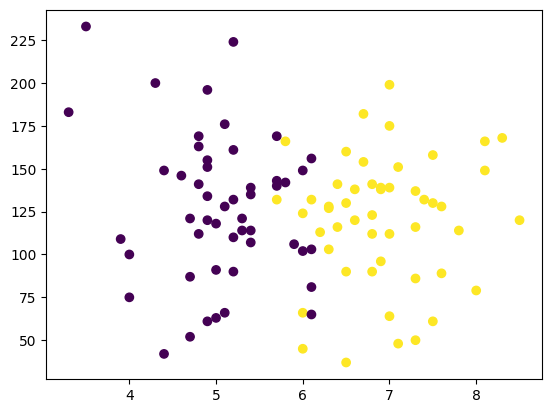

In [71]:
plt.scatter(data['cgpa'],data['iq'],c=data['placement'])
# plotting the data in various ways go get a clr picture of the data

In [72]:
# we gonna use the logistic regression to diffrenciate the data using a line to divide the data between the placed students and non placed students
X=data.iloc[:,:2] # input for training the data
Y=data.iloc[:,-1] # output that is expected to come

In [73]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)
# this is used to split the data into training and testing data

In [74]:
from sklearn.preprocessing import  StandardScaler
scaler=StandardScaler()

In [75]:
X_train=scaler.fit_transform(X_train)
# this is used to fit and transform the data into a standard form
X_train

array([[ 0.85143332, -0.71958265],
       [ 0.4044867 ,  0.40770087],
       [-0.48940655, -0.26866924],
       [ 0.49387602,  0.13214268],
       [ 0.13631872,  0.78346205],
       [-0.48940655,  0.2573964 ],
       [-0.93635318,  0.65820832],
       [ 0.94082264,  1.86064408],
       [-1.7408571 , -1.24564829],
       [ 0.76204399,  0.40770087],
       [-1.11513183, -0.94503935],
       [ 0.49387602, -2.1975766 ],
       [ 1.29837994,  0.18224417],
       [-1.47268913,  1.88569482],
       [ 1.03021197,  0.65820832],
       [ 0.58326535, -0.11836477],
       [-0.84696385, -0.84483637],
       [-0.84696385, -1.54625723],
       [-0.6681852 , -0.86988712],
       [ 0.76204399, -0.86988712],
       [-2.36658238,  1.45983216],
       [ 0.0469294 , -1.47110499],
       [-0.84696385, -0.16846626],
       [-0.48940655,  0.35759938],
       [-1.7408571 , -0.61937967],
       [ 0.94082264, -0.31877073],
       [-0.57879588, -0.09331402],
       [ 0.76204399, -0.04321253],
       [ 0.49387602,

In [76]:
X_test=scaler.transform(X_test)

In [77]:
from sklearn.linear_model import LogisticRegression

In [78]:
clf=LogisticRegression()
clf.fit(X_train,Y_train)
# this is used to fit the data into the model , which is used to train the model

LogisticRegression()

In [79]:
Y_pred=clf.predict(X_test)
# using the predict method we can predict the output of the model using the test data this can be used to check the accuracy of the model on the test data

In [80]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)
# this checks the accuracy of the model

0.95

<Axes: >

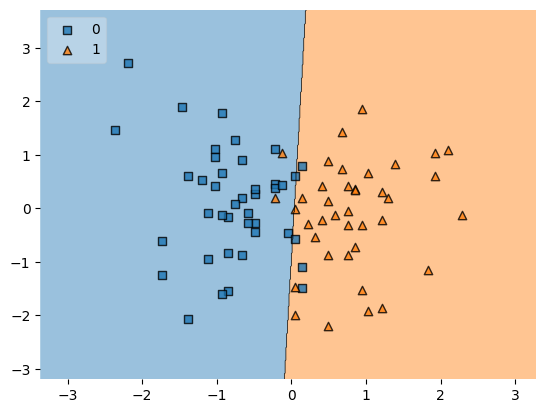

In [81]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2)
# this helps to plot the decision regions of the model and help us understand how the model has been trained

In [83]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))
# this is used to export the model to a file so that it can be used to deploy the model in the web application